
# GVH Diagonal Cubic 0.2.21 — Equivalence Principle and PPN Constraints
## Principe d’équivalence, paramètres post-newtoniens et tests du Système solaire

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.20 a proposé une métrique effective candidate :

\[
g_{\mu\nu}^{\rm eff}
=
g_{\mu\nu}
+
\epsilon_D \bar D_{\mu\nu}.
\]

Cette version confronte ce couplage aux tests de précision de la gravitation faible.

Les objectifs sont :

1. écrire la métrique effective dans le formalisme PPN ;
2. identifier les corrections candidates à \(\gamma\) et \(\beta\) ;
3. tester la chute libre universelle ;
4. calculer le redshift gravitationnel ;
5. calculer la déviation de la lumière ;
6. calculer le retard de Shapiro ;
7. calculer la précession du périhélie ;
8. traduire les mesures expérimentales en contraintes sur les paramètres GVH.

---

## Portée scientifique

Ce notebook ne dérive pas encore \(\gamma_{\rm GVH}\) et \(\beta_{\rm GVH}\) depuis l’action complète.

Il introduit une **interface PPN falsifiable** :

\[
(\epsilon_D,\alpha_D,\beta_D,\gamma_D,\delta_s)
\longrightarrow
\text{observables mesurables}.
\]

Les limites numériques sont donc des contraintes conditionnelles sur les paramètres candidats.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Métrique PPN statique et isotrope

À l’ordre post-newtonien, une métrique sphérique faible peut s’écrire :

\[
g_{00}
=
-1
+
\frac{2U}{c^2}
-
2\beta
\frac{U^2}{c^4}
+
\mathcal O(c^{-6}),
\]

\[
g_{0i}
=
0
\]

dans le cas statique simplifié, et :

\[
g_{ij}
=
\left(
1
+
2\gamma
\frac{U}{c^2}
\right)
\delta_{ij}
+
\mathcal O(c^{-4}).
\]

En relativité générale :

\[
\gamma_{\rm GR}=1,
\qquad
\beta_{\rm GR}=1.
\]


In [2]:

U, c = sp.symbols(
    "U c",
    positive=True,
    real=True
)

gamma_ppn, beta_ppn = sp.symbols(
    "gamma_ppn beta_ppn",
    real=True
)

g00_ppn = sp.simplify(
    -1
    + 2*U/c**2
    - 2*beta_ppn*U**2/c**4
)

gii_ppn = sp.simplify(
    1
    + 2*gamma_ppn*U/c**2
)

display(g00_ppn)
display(gii_ppn)


     2               
  2⋅U ⋅βₚₚₙ   2⋅U    
- ───────── + ─── - 1
      4        2     
     c        c      

2⋅U⋅γₚₚₙ    
──────── + 1
    2       
   c        


# 2. Paramétrisation PPN candidate de GVH

Nous écrivons :

\[
\gamma_{\rm eff}
=
1+\Delta\gamma_{\rm GVH},
\]

\[
\beta_{\rm eff}
=
1+\Delta\beta_{\rm GVH}.
\]

Une interface linéaire minimale est :

\[
\Delta\gamma_{\rm GVH}
=
\epsilon_D\gamma_D,
\]

\[
\Delta\beta_{\rm GVH}
=
\epsilon_D\beta_D.
\]

Cette écriture ne constitue pas encore une dérivation fondamentale : elle permet de transformer directement les tests PPN en contraintes.


In [3]:

epsilon_D, gamma_D, beta_D = sp.symbols(
    "epsilon_D gamma_D beta_D",
    real=True
)

Delta_gamma = sp.simplify(
    epsilon_D*gamma_D
)

Delta_beta = sp.simplify(
    epsilon_D*beta_D
)

gamma_eff = sp.simplify(
    1+Delta_gamma
)

beta_eff = sp.simplify(
    1+Delta_beta
)

display(gamma_eff)
display(beta_eff)


ε_D⋅γ_D + 1

β_D⋅ε_D + 1


# 3. Références expérimentales utilisées

Les valeurs de référence inscrites dans ce notebook sont :

### Cassini — paramètre \(\gamma\)

\[
\gamma-1
=
(2.1\pm2.3)\times10^{-5}.
\]

Référence : B. Bertotti, L. Iess et P. Tortora, *Nature* **425**, 374–376 (2003), DOI `10.1038/nature01997`.

### MICROSCOPE — principe d’équivalence faible

\[
\eta({\rm Ti,Pt})
=
[-1.5
\pm2.3_{\rm stat}
\pm1.5_{\rm syst}]
\times10^{-15}.
\]

Référence : P. Touboul et al., *Physical Review Letters* **129**, 121102 (2022), DOI `10.1103/PhysRevLett.129.121102`.

### Galileo — redshift gravitationnel

\[
\alpha_{\rm redshift}
=
(0.19\pm2.48)\times10^{-5}
\]

pour la déviation fractionnelle à la prédiction de la relativité générale.

Référence : P. Delva et al., *Physical Review Letters* **121**, 231101 (2018), DOI `10.1103/PhysRevLett.121.231101`.

### Lunar Laser Ranging — paramètres \(\eta_N\) et \(\beta\)

Une référence historique de travail donne :

\[
\eta_N
=
(4.4\pm4.5)\times10^{-4},
\]

\[
\beta-1
=
(1.2\pm1.1)\times10^{-4}.
\]

Référence : J. G. Williams, S. G. Turyshev et D. H. Boggs, arXiv:`gr-qc/0507083`.

Ces nombres sont utilisés comme benchmarks numériques, pas comme une compilation exhaustive de toutes les contraintes modernes.


In [4]:

experimental_benchmarks = pd.DataFrame([
    {
        "test":"Cassini gamma",
        "central":2.1e-5,
        "sigma_stat":2.3e-5,
        "sigma_syst":0.0,
        "quantity":"gamma - 1"
    },
    {
        "test":"MICROSCOPE WEP",
        "central":-1.5e-15,
        "sigma_stat":2.3e-15,
        "sigma_syst":1.5e-15,
        "quantity":"eta(Ti,Pt)"
    },
    {
        "test":"Galileo redshift",
        "central":0.19e-5,
        "sigma_stat":2.48e-5,
        "sigma_syst":0.0,
        "quantity":"alpha_redshift"
    },
    {
        "test":"LLR Nordtvedt",
        "central":4.4e-4,
        "sigma_stat":4.5e-4,
        "sigma_syst":0.0,
        "quantity":"eta_N"
    },
    {
        "test":"LLR beta",
        "central":1.2e-4,
        "sigma_stat":1.1e-4,
        "sigma_syst":0.0,
        "quantity":"beta - 1"
    }
])

experimental_benchmarks["sigma_total"] = np.sqrt(
    experimental_benchmarks["sigma_stat"]**2
    + experimental_benchmarks["sigma_syst"]**2
)

experimental_benchmarks


,test,central,sigma_stat,sigma_syst,quantity,sigma_total
0,Cassini gamma,2.100000e-05,2.300000e-05,0.000000e+00,gamma - 1,2.300000e-05
1,MICROSCOPE WEP,-1.500000e-15,2.300000e-15,1.500000e-15,"eta(Ti,Pt)",2.745906e-15
2,Galileo redshift,1.900000e-06,2.480000e-05,0.000000e+00,alpha_redshift,2.480000e-05
3,LLR Nordtvedt,4.400000e-04,4.500000e-04,0.000000e+00,eta_N,4.500000e-04
4,LLR beta,1.200000e-04,1.100000e-04,0.000000e+00,beta - 1,1.100000e-04



# 4. Principe d’équivalence faible

Pour deux espèces \(A\) et \(B\) :

\[
\eta_{AB}
=
\frac{2(a_A-a_B)}
{a_A+a_B}.
\]

Nous paramétrons un couplage non universel par :

\[
\epsilon_A
=
\epsilon_D(1+\delta_A),
\]

\[
\epsilon_B
=
\epsilon_D(1+\delta_B).
\]

À faible correction, un modèle schématique donne :

\[
\eta_{AB}
\approx
\epsilon_D
(\delta_A-\delta_B)
\mathcal S_D,
\]

où \(\mathcal S_D\) mesure la sensibilité de l’accélération au champ directionnel.


In [5]:

delta_A, delta_B, S_D = sp.symbols(
    "delta_A delta_B S_D",
    real=True
)

eta_candidate = sp.simplify(
    epsilon_D
    * (delta_A-delta_B)
    * S_D
)

display(eta_candidate)


S_D⋅ε_D⋅(δ_A - δ_B)


# 5. Contrainte MICROSCOPE conditionnelle

À titre conservateur, nous construisons une enveloppe \(2\sigma\) :

\[
|\eta_{\rm GVH}|
\lesssim
|\eta_0|
+
2\sigma_{\rm total}.
\]

Cela contraint :

\[
\left|
\epsilon_D
(\delta_{\rm Ti}-\delta_{\rm Pt})
\mathcal S_D
\right|
\lesssim
\eta_{\max}.
\]


In [6]:

micro = experimental_benchmarks.loc[
    experimental_benchmarks["test"]=="MICROSCOPE WEP"
].iloc[0]

eta_micro_2sigma = (
    abs(micro["central"])
    + 2*micro["sigma_total"]
)

print("Enveloppe MICROSCOPE 2 sigma :",eta_micro_2sigma)


Enveloppe MICROSCOPE 2 sigma : 6.991812087098392e-15



# 6. Redshift gravitationnel

Pour deux horloges immobiles dans des potentiels \(U_1,U_2\) :

\[
\frac{\Delta\nu}{\nu}
\approx
\frac{U_1-U_2}{c^2}.
\]

Nous introduisons une correction GVH :

\[
\left(
\frac{\Delta\nu}{\nu}
\right)_{\rm GVH}
=
(1+\alpha_D^{\rm eff})
\frac{\Delta U}{c^2}.
\]

Avec une interface minimale :

\[
\alpha_D^{\rm eff}
=
\epsilon_D\alpha_D.
\]


In [7]:

alpha_D = sp.symbols(
    "alpha_D",
    real=True
)

alpha_eff = sp.simplify(
    epsilon_D*alpha_D
)

Delta_U = sp.symbols(
    "Delta_U",
    real=True
)

redshift_GVH = sp.simplify(
    (1+alpha_eff)
    * Delta_U/c**2
)

display(redshift_GVH)


Δ_U⋅(α_D⋅ε_D + 1)
─────────────────
        2        
       c         


# 7. Contrainte Galileo conditionnelle

Le benchmark Galileo est utilisé pour borner :

\[
|\epsilon_D\alpha_D|.
\]

Une enveloppe \(2\sigma\) est calculée.


In [8]:

galileo = experimental_benchmarks.loc[
    experimental_benchmarks["test"]=="Galileo redshift"
].iloc[0]

alpha_redshift_2sigma = (
    abs(galileo["central"])
    + 2*galileo["sigma_total"]
)

print(
    "Enveloppe redshift 2 sigma :",
    alpha_redshift_2sigma
)


Enveloppe redshift 2 sigma : 5.15e-05



# 8. Déviation de la lumière

Dans le formalisme PPN, la déviation d’un rayon lumineux passant à une distance d’impact \(b\) d’une masse \(M\) est :

\[
\delta\theta
=
(1+\gamma)
\frac{2GM}{bc^2}.
\]

En relativité générale :

\[
\delta\theta_{\rm GR}
=
\frac{4GM}{bc^2}.
\]

Le rapport est :

\[
\frac{\delta\theta_{\rm GVH}}
{\delta\theta_{\rm GR}}
=
\frac{1+\gamma_{\rm eff}}{2}.
\]


In [9]:

G, M, b = sp.symbols(
    "G M b",
    positive=True,
    real=True
)

light_deflection = sp.simplify(
    (1+gamma_eff)
    * 2*G*M/(b*c**2)
)

light_deflection_GR = sp.simplify(
    4*G*M/(b*c**2)
)

deflection_ratio = sp.simplify(
    light_deflection/light_deflection_GR
)

display(light_deflection)
display(deflection_ratio)


2⋅G⋅M⋅(ε_D⋅γ_D + 2)
───────────────────
          2        
       b⋅c         

ε_D⋅γ_D    
─────── + 1
   2       


# 9. Retard de Shapiro

Pour un trajet radar autour d’une masse, le terme dominant est proportionnel à :

\[
\Delta t_{\rm Shapiro}
\propto
(1+\gamma)
\frac{GM}{c^3}
\ln(\text{géométrie du trajet}).
\]

La correction relative au résultat GR est donc :

\[
\frac{\Delta t_{\rm GVH}}
{\Delta t_{\rm GR}}
=
\frac{1+\gamma_{\rm eff}}{2}.
\]

Cassini contraint directement cette combinaison.


In [10]:

shapiro_ratio = sp.simplify(
    (1+gamma_eff)/2
)

display(shapiro_ratio)


ε_D⋅γ_D    
─────── + 1
   2       


# 10. Contrainte Cassini sur le secteur spatial

Le benchmark Cassini impose conditionnellement :

\[
|\epsilon_D\gamma_D|
\lesssim
|\gamma_0-1|
+
2\sigma_\gamma.
\]


In [11]:

cassini = experimental_benchmarks.loc[
    experimental_benchmarks["test"]=="Cassini gamma"
].iloc[0]

gamma_2sigma = (
    abs(cassini["central"])
    + 2*cassini["sigma_total"]
)

print("Enveloppe Cassini 2 sigma :",gamma_2sigma)


Enveloppe Cassini 2 sigma : 6.7e-05



# 11. Précession du périhélie

Dans une théorie PPN conservatrice simplifiée, la correction à la précession de GR est contrôlée par :

\[
\frac{2+2\gamma-\beta}{3}.
\]

Ainsi :

\[
\Delta\varpi_{\rm PPN}
=
\Delta\varpi_{\rm GR}
\frac{2+2\gamma_{\rm eff}-\beta_{\rm eff}}{3}.
\]

Avec :

\[
\Delta\varpi_{\rm GR}
=
\frac{6\pi GM}
{a(1-e^2)c^2}.
\]


In [12]:

a_orbit, eccentricity = sp.symbols(
    "a_orbit eccentricity",
    positive=True,
    real=True
)

perihelion_GR = sp.simplify(
    6*sp.pi*G*M
    / (
        a_orbit
        * (1-eccentricity**2)
        * c**2
    )
)

perihelion_factor = sp.simplify(
    (
        2
        + 2*gamma_eff
        - beta_eff
    )/3
)

perihelion_GVH = sp.simplify(
    perihelion_GR*perihelion_factor
)

display(perihelion_factor)
display(perihelion_GVH)


  β_D⋅ε_D   2⋅ε_D⋅γ_D    
- ─────── + ───────── + 1
     3          3        

2⋅π⋅G⋅M⋅(β_D⋅ε_D - 2⋅ε_D⋅γ_D - 3)
─────────────────────────────────
          2 ⎛            2    ⎞  
 a_orbit⋅c ⋅⎝eccentricity  - 1⎠  


# 12. Paramètre de Nordtvedt

Dans le sous-ensemble PPN usuel :

\[
\eta_N
=
4\beta-\gamma-3.
\]

Pour l’interface GVH :

\[
\eta_N^{\rm GVH}
=
4\Delta\beta_{\rm GVH}
-
\Delta\gamma_{\rm GVH}.
\]

Donc :

\[
\eta_N^{\rm GVH}
=
\epsilon_D
(4\beta_D-\gamma_D).
\]


In [13]:

eta_N_GVH = sp.simplify(
    4*beta_eff
    - gamma_eff
    - 3
)

display(eta_N_GVH)


ε_D⋅(4⋅β_D - γ_D)


# 13. Contraintes combinées sur \(\Delta\gamma\) et \(\Delta\beta\)

Nous utilisons trois bandes conditionnelles :

1. Cassini :
   \[
   |\Delta\gamma|
   \lesssim B_\gamma;
   \]

2. LLR sur \(\beta\) :
   \[
   |\Delta\beta|
   \lesssim B_\beta;
   \]

3. Nordtvedt :
   \[
   |4\Delta\beta-\Delta\gamma|
   \lesssim B_{\eta_N}.
   \]

Leur intersection définit une région admissible approximative.


In [14]:

llr_beta = experimental_benchmarks.loc[
    experimental_benchmarks["test"]=="LLR beta"
].iloc[0]

llr_eta = experimental_benchmarks.loc[
    experimental_benchmarks["test"]=="LLR Nordtvedt"
].iloc[0]

beta_2sigma = (
    abs(llr_beta["central"])
    + 2*llr_beta["sigma_total"]
)

etaN_2sigma = (
    abs(llr_eta["central"])
    + 2*llr_eta["sigma_total"]
)

print("B_gamma =",gamma_2sigma)
print("B_beta =",beta_2sigma)
print("B_eta_N =",etaN_2sigma)


B_gamma = 6.7e-05
B_beta = 0.00034
B_eta_N = 0.00134


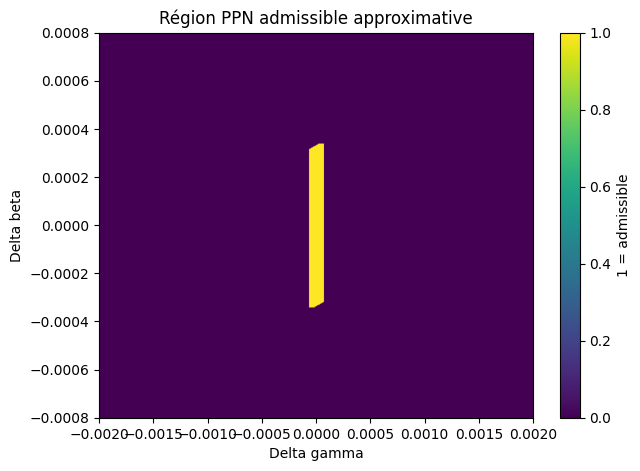

In [15]:

dg = np.linspace(
    -2e-3,
    2e-3,
    700
)

db = np.linspace(
    -8e-4,
    8e-4,
    700
)

DG, DB = np.meshgrid(
    dg,
    db
)

allowed = (
    (np.abs(DG) <= gamma_2sigma)
    & (np.abs(DB) <= beta_2sigma)
    & (np.abs(4*DB-DG) <= etaN_2sigma)
)

plt.figure(figsize=(7,5))
plt.imshow(
    allowed.astype(float),
    origin="lower",
    extent=[
        dg.min(),
        dg.max(),
        db.min(),
        db.max()
    ],
    aspect="auto"
)
plt.xlabel("Delta gamma")
plt.ylabel("Delta beta")
plt.title("Région PPN admissible approximative")
plt.colorbar(label="1 = admissible")
plt.show()



# 14. Conversion en bornes sur \(\epsilon_D\)

Pour un coefficient théorique non nul \(C\) :

\[
|\epsilon_D C|
<
B
\]

implique :

\[
|\epsilon_D|
<
\frac{B}{|C|}.
\]

Nous construisons une fonction générique pour :

- \(\gamma_D\) ;
- \(\beta_D\) ;
- \(\alpha_D\) ;
- \((\delta_A-\delta_B)\mathcal S_D\).


In [16]:

def epsilon_bound(observational_bound,theory_coefficient):
    coeff = abs(float(theory_coefficient))

    if coeff == 0:
        return np.inf

    return observational_bound/coeff


theory_coefficients = {
    "gamma_D":1.0,
    "beta_D":1.0,
    "alpha_D":1.0,
    "composition_sensitivity":1.0
}

epsilon_bounds = pd.DataFrame([
    {
        "channel":"Cassini gamma",
        "coefficient":"gamma_D",
        "coefficient_value":theory_coefficients["gamma_D"],
        "epsilon_abs_max":epsilon_bound(
            gamma_2sigma,
            theory_coefficients["gamma_D"]
        )
    },
    {
        "channel":"LLR beta",
        "coefficient":"beta_D",
        "coefficient_value":theory_coefficients["beta_D"],
        "epsilon_abs_max":epsilon_bound(
            beta_2sigma,
            theory_coefficients["beta_D"]
        )
    },
    {
        "channel":"Galileo redshift",
        "coefficient":"alpha_D",
        "coefficient_value":theory_coefficients["alpha_D"],
        "epsilon_abs_max":epsilon_bound(
            alpha_redshift_2sigma,
            theory_coefficients["alpha_D"]
        )
    },
    {
        "channel":"MICROSCOPE WEP",
        "coefficient":"composition_sensitivity",
        "coefficient_value":theory_coefficients["composition_sensitivity"],
        "epsilon_abs_max":epsilon_bound(
            eta_micro_2sigma,
            theory_coefficients["composition_sensitivity"]
        )
    }
])

epsilon_bounds


,channel,coefficient,coefficient_value,epsilon_abs_max
0,Cassini gamma,gamma_D,1.0,6.700000e-05
1,LLR beta,beta_D,1.0,3.400000e-04
2,Galileo redshift,alpha_D,1.0,5.150000e-05
3,MICROSCOPE WEP,composition_sensitivity,1.0,6.991812e-15



# 15. Hiérarchie des contraintes

Le canal le plus contraignant dépend de la structure théorique.

- Si le couplage est universel :
  \[
  \delta_A-\delta_B=0,
  \]
  et MICROSCOPE ne borne pas directement \(\epsilon_D\).

- Si le secteur directionnel ne modifie que \(g_{ij}\), Cassini peut être le test dominant.

- Si une correction à \(g_{00}\) existe, le redshift et les horloges deviennent importants.

- Si \(\Delta\beta\neq0\), le périhélie et le LLR contraignent le modèle.

La valeur brute de \(\epsilon_D\) ne peut donc pas être bornée sans connaître les coefficients \(\gamma_D,\beta_D,\alpha_D\).


In [17]:

hierarchy_table = pd.DataFrame([
    {
        "model_feature":"universal matter coupling",
        "dominant_test":"PPN gamma, beta, redshift",
        "WEP_test":"automatically passed at leading order"
    },
    {
        "model_feature":"composition-dependent coupling",
        "dominant_test":"MICROSCOPE",
        "WEP_test":"very restrictive"
    },
    {
        "model_feature":"spatial metric correction",
        "dominant_test":"Cassini / light propagation",
        "WEP_test":"secondary"
    },
    {
        "model_feature":"temporal metric correction",
        "dominant_test":"redshift / orbital dynamics",
        "WEP_test":"depends on universality"
    }
])

hierarchy_table


,model_feature,dominant_test,WEP_test
0,universal matter coupling,"PPN gamma, beta, redshift",automatically passed at leading order
1,composition-dependent coupling,MICROSCOPE,very restrictive
2,spatial metric correction,Cassini / light propagation,secondary
3,temporal metric correction,redshift / orbital dynamics,depends on universality



# 16. Exemple numérique pour le Soleil

Nous évaluons la déviation de la lumière au bord solaire avec :

\[
\gamma_{\rm eff}=1+\Delta\gamma.
\]

Les constantes numériques sont utilisées uniquement comme démonstration du pipeline.


In [18]:

G_num = 6.67430e-11
M_sun = 1.98847e30
R_sun = 6.957e8
c_num = 299792458.0

def light_deflection_arcsec(
    delta_gamma
):
    gamma_value = 1+delta_gamma

    angle_rad = (
        (1+gamma_value)
        * 2
        * G_num
        * M_sun
        / (
            R_sun
            * c_num**2
        )
    )

    return (
        angle_rad
        * 180/np.pi
        * 3600
    )


deflection_examples = pd.DataFrame([
    {
        "Delta_gamma":value,
        "deflection_arcsec":light_deflection_arcsec(
            value
        )
    }
    for value in [
        0.0,
        gamma_2sigma,
        -gamma_2sigma
    ]
])

deflection_examples


,Delta_gamma,deflection_arcsec
0,0.000000,1.751243
1,0.000067,1.751302
2,-0.000067,1.751185



# 17. Précession de Mercure

Nous évaluons :

\[
\Delta\varpi
=
\frac{6\pi GM_\odot}
{a(1-e^2)c^2}
\frac{2+2\gamma-\beta}{3}.
\]

Le résultat est donné par orbite et par siècle.


In [19]:

a_mercury = 5.790905e10
e_mercury = 0.205630
period_mercury_days = 87.9691

def perihelion_arcsec_per_century(
    delta_gamma,
    delta_beta
):
    gamma_value = 1+delta_gamma
    beta_value = 1+delta_beta

    per_orbit_rad = (
        6*np.pi
        * G_num
        * M_sun
        / (
            a_mercury
            * (
                1-e_mercury**2
            )
            * c_num**2
        )
    )

    ppn_factor = (
        2
        + 2*gamma_value
        - beta_value
    )/3

    orbits_per_century = (
        36525
        / period_mercury_days
    )

    return (
        per_orbit_rad
        * ppn_factor
        * orbits_per_century
        * 180/np.pi
        * 3600
    )


mercury_examples = pd.DataFrame([
    {
        "Delta_gamma":dgamma,
        "Delta_beta":dbeta,
        "arcsec_per_century":perihelion_arcsec_per_century(
            dgamma,
            dbeta
        )
    }
    for dgamma,dbeta in [
        (0.0,0.0),
        (gamma_2sigma,0.0),
        (0.0,beta_2sigma),
        (gamma_2sigma,beta_2sigma)
    ]
])

mercury_examples


,Delta_gamma,Delta_beta,arcsec_per_century
0,0.000000,0.00000,42.981975
1,0.000067,0.00000,42.983895
2,0.000000,0.00034,42.977104
3,0.000067,0.00034,42.979024



# 18. Décision automatique d’admissibilité

Nous définissons un point candidat :

\[
(\Delta\gamma,\Delta\beta,\alpha_{\rm redshift},\eta_{\rm WEP}).
\]

Il est classé `PASS-BENCHMARKS` s’il respecte les enveloppes adoptées.


In [20]:

def classify_candidate(
    delta_gamma,
    delta_beta,
    alpha_redshift,
    eta_wep
):
    tests = {
        "Cassini_gamma":abs(delta_gamma) <= gamma_2sigma,
        "LLR_beta":abs(delta_beta) <= beta_2sigma,
        "Nordtvedt":abs(
            4*delta_beta-delta_gamma
        ) <= etaN_2sigma,
        "Galileo_redshift":abs(
            alpha_redshift
        ) <= alpha_redshift_2sigma,
        "MICROSCOPE_WEP":abs(
            eta_wep
        ) <= eta_micro_2sigma
    }

    status = (
        "PASS-BENCHMARKS"
        if all(tests.values())
        else "REJECT-BENCHMARKS"
    )

    return status,tests


candidate_examples = []

for candidate in [
    {
        "name":"GR limit",
        "delta_gamma":0.0,
        "delta_beta":0.0,
        "alpha_redshift":0.0,
        "eta_wep":0.0
    },
    {
        "name":"small universal GVH",
        "delta_gamma":1e-5,
        "delta_beta":2e-5,
        "alpha_redshift":1e-5,
        "eta_wep":0.0
    },
    {
        "name":"composition-dependent example",
        "delta_gamma":1e-5,
        "delta_beta":2e-5,
        "alpha_redshift":1e-5,
        "eta_wep":1e-10
    }
]:
    status,tests = classify_candidate(
        candidate["delta_gamma"],
        candidate["delta_beta"],
        candidate["alpha_redshift"],
        candidate["eta_wep"]
    )

    candidate_examples.append({
        **candidate,
        "status":status,
        **tests
    })

candidate_df = pd.DataFrame(
    candidate_examples
)

candidate_df


,name,delta_gamma,delta_beta,alpha_redshift,eta_wep,status,Cassini_gamma,LLR_beta,Nordtvedt,Galileo_redshift,MICROSCOPE_WEP
0,GR limit,0.00000,0.00000,0.00000,0.000000e+00,PASS-BENCHMARKS,True,True,True,True,True
1,small universal GVH,0.00001,0.00002,0.00001,0.000000e+00,PASS-BENCHMARKS,True,True,True,True,True
2,composition-dependent example,0.00001,0.00002,0.00001,1.000000e-10,REJECT-BENCHMARKS,True,True,True,True,False



# 19. Interprétation pour le modèle Diagonal Cubic

Le secteur spatial sans trace développé dans 0.2.12–0.2.20 peut affecter principalement :

\[
g_{ij}.
\]

Cela suggère une première association possible :

\[
\Delta\gamma_{\rm GVH}
\neq0,
\]

alors que :

\[
\Delta\beta_{\rm GVH}
\]

et le redshift peuvent rester faibles si aucune correction temporelle n’est induite.

Cette association est une **hypothèse de travail**, pas encore un résultat dérivé.

La prochaine dérivation essentielle devra montrer comment la solution statique du champ \(D_{\mu\nu}\) modifie exactement :

\[
g_{00},
\qquad
g_{rr},
\qquad
g_{\theta\theta},
\qquad
g_{\phi\phi}.
\]


In [21]:

interpretation_status = pd.DataFrame([
    {
        "quantity":"Delta gamma",
        "possible_origin":"spatial metric correction",
        "derivation_status":"not yet derived"
    },
    {
        "quantity":"Delta beta",
        "possible_origin":"nonlinear temporal metric correction",
        "derivation_status":"not yet derived"
    },
    {
        "quantity":"alpha_redshift",
        "possible_origin":"g00 correction or clock coupling",
        "derivation_status":"not yet derived"
    },
    {
        "quantity":"eta_WEP",
        "possible_origin":"composition-dependent matter coupling",
        "derivation_status":"zero if coupling universal"
    }
])

interpretation_status


,quantity,possible_origin,derivation_status
0,Delta gamma,spatial metric correction,not yet derived
1,Delta beta,nonlinear temporal metric correction,not yet derived
2,alpha_redshift,g00 correction or clock coupling,not yet derived
3,eta_WEP,composition-dependent matter coupling,zero if coupling universal



# 20. Validation automatique

Le notebook vérifie :

1. la limite GR :
   \[
   \gamma=\beta=1;
   \]

2. la formule de déviation lumineuse ;

3. la formule du facteur de périhélie ;

4. la relation de Nordtvedt ;

5. l’acceptation automatique de la limite GR ;

6. le rejet d’un exemple violant fortement le principe d’équivalence.


In [22]:

gr_limit_ok = (
    gamma_eff.subs(
        epsilon_D,
        0
    ) == 1
    and beta_eff.subs(
        epsilon_D,
        0
    ) == 1
)

deflection_ratio_ok = (
    sp.simplify(
        deflection_ratio
        - (
            1+gamma_eff
        )/2
    ) == 0
)

perihelion_factor_ok = (
    sp.simplify(
        perihelion_factor
        - (
            2
            + 2*gamma_eff
            - beta_eff
        )/3
    ) == 0
)

nordtvedt_ok = (
    sp.simplify(
        eta_N_GVH
        - epsilon_D*(
            4*beta_D
            - gamma_D
        )
    ) == 0
)

gr_candidate_ok = (
    candidate_df.loc[
        candidate_df["name"]=="GR limit",
        "status"
    ].iloc[0]
    == "PASS-BENCHMARKS"
)

wep_rejection_ok = (
    candidate_df.loc[
        candidate_df["name"]
        == "composition-dependent example",
        "status"
    ].iloc[0]
    == "REJECT-BENCHMARKS"
)

validation_df = pd.DataFrame([
    {
        "test":"GR PPN limit",
        "status":"PASS" if gr_limit_ok else "FAIL"
    },
    {
        "test":"light-deflection ratio",
        "status":"PASS" if deflection_ratio_ok else "FAIL"
    },
    {
        "test":"perihelion PPN factor",
        "status":"PASS" if perihelion_factor_ok else "FAIL"
    },
    {
        "test":"Nordtvedt relation",
        "status":"PASS" if nordtvedt_ok else "FAIL"
    },
    {
        "test":"GR candidate accepted",
        "status":"PASS" if gr_candidate_ok else "FAIL"
    },
    {
        "test":"large WEP violation rejected",
        "status":"PASS" if wep_rejection_ok else "FAIL"
    }
])

validation_df


,test,status
0,GR PPN limit,PASS
1,light-deflection ratio,PASS
2,perihelion PPN factor,PASS
3,Nordtvedt relation,PASS
4,GR candidate accepted,PASS
5,large WEP violation rejected,PASS


In [23]:

overall_status = (
    "PASS-PPN-INTERFACE"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)
print("PARAMÈTRES PPN GVH DÉRIVÉS DE L’ACTION : NON ENCORE")


STATUT DU NOTEBOOK : PASS-PPN-INTERFACE
PARAMÈTRES PPN GVH DÉRIVÉS DE L’ACTION : NON ENCORE



# 21. Export


In [24]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Validation.csv",
    index=False
)

experimental_benchmarks.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Experimental_Benchmarks.csv",
    index=False
)

epsilon_bounds.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Epsilon_Bounds.csv",
    index=False
)

candidate_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Candidate_Classification.csv",
    index=False
)

deflection_examples.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Light_Deflection.csv",
    index=False
)

mercury_examples.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Mercury_Precession.csv",
    index=False
)

interpretation_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.21_Interpretation_Status.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "PPN_interface":{
        "gamma_eff":"1 + epsilon_D gamma_D",
        "beta_eff":"1 + epsilon_D beta_D",
        "redshift_alpha":"epsilon_D alpha_D",
        "WEP_eta":"epsilon_D(delta_A-delta_B)S_D"
    },
    "benchmark_bounds_2sigma":{
        "abs_Delta_gamma":float(gamma_2sigma),
        "abs_Delta_beta":float(beta_2sigma),
        "abs_alpha_redshift":float(alpha_redshift_2sigma),
        "abs_eta_WEP":float(eta_micro_2sigma),
        "abs_eta_Nordtvedt":float(etaN_2sigma)
    },
    "main_result":"falsifiable PPN constraint interface constructed",
    "main_open_problem":"derive gamma_D, beta_D and alpha_D from the static GVH field solution"
}

with open(
    "GVH_Diagonal_Cubic_0.2.21_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 22. Conclusion scientifique

La métrique PPN candidate est définie par :

\[
\boxed{
\gamma_{\rm eff}
=
1+\epsilon_D\gamma_D
}
\]

et :

\[
\boxed{
\beta_{\rm eff}
=
1+\epsilon_D\beta_D
}.
\]

Le principe d’équivalence faible impose, dans un modèle non universel :

\[
\boxed{
\left|
\epsilon_D
(\delta_A-\delta_B)
\mathcal S_D
\right|
\lesssim
\eta_{\max}
}.
\]

La propagation de la lumière contraint :

\[
\boxed{
|\epsilon_D\gamma_D|
\lesssim
B_\gamma
}.
\]

Le redshift contraint :

\[
\boxed{
|\epsilon_D\alpha_D|
\lesssim
B_{\rm redshift}
}.
\]

La dynamique orbitale contraint :

\[
\boxed{
|\epsilon_D\beta_D|
\lesssim
B_\beta
}
\]

et :

\[
\boxed{
|\epsilon_D(4\beta_D-\gamma_D)|
\lesssim
B_{\eta_N}
}.
\]

Le notebook transforme donc le modèle GVH en une interface directement falsifiable par les tests du Système solaire.

Cependant, il manque encore l’étape essentielle :

\[
\boxed{
\gamma_D,\beta_D,\alpha_D
\text{ doivent être dérivés de la solution statique de l’action GVH}
}.
\]

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.22\_Static\_Spherical\_Solution\_PPN\_Derivation.ipynb}
}
\]

Elle devra :

- résoudre les équations de champ statiques et sphériques ;
- obtenir \(g_{tt}(r)\) et \(g_{rr}(r)\) ;
- développer la solution en puissances de \(GM/(rc^2)\) ;
- dériver \(\gamma_{\rm GVH}\) et \(\beta_{\rm GVH}\) ;
- remplacer les coefficients PPN libres par des prédictions du modèle ;
- décider si le modèle passe réellement les tests de précision.
